# Clustering Algorithms (Revised)
# K-Means & DBSCAN

### Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist

### Data Loading and Preprocessing

In [2]:
# df_fact = pd.read_csv("/kaggle/input/datasets/marwannegm/aaaaaaaa/steamUserFact.csv")
# df_user = pd.read_csv("/kaggle/input/datasets/marwannegm/aaaaaaaa/userDim.csv")
# df_game = pd.read_csv("/kaggle/input/datasets/marwannegm/aaaaaaaa/gameDim.csv", encoding="latin-1")

df_fact = pd.read_csv("C:/Users/mazen/OneDrive/Desktop/steamUserFact.csv")
df_user = pd.read_csv("C:/Users/mazen/OneDrive/Desktop/userDim.csv")
df_game = pd.read_csv("C:/Users/mazen/OneDrive/Desktop/gameDim.csv", encoding="latin-1")

df_game['price_clean'] = pd.to_numeric(df_game['price']).fillna(0)

df_merged = df_fact.merge(df_game, on='game_id', how='inner')

user_stats = df_merged.groupby('steam_id').agg(
    total_games=('game_id', 'count'),
    total_playtime=('playtime_hours', 'sum'),
    avg_price=('price_clean', 'mean')
).reset_index()

df_genres = df_merged[['steam_id', 'genres']].copy()
df_genres['genres'] = df_genres['genres'].fillna('Unknown').astype(str).str.split(',')
df_exploded = df_genres.explode('genres')

genre_counts = df_exploded.groupby(['steam_id', 'genres']).size().unstack(fill_value=0)
top_genres = df_exploded['genres'].value_counts().head(8).index.tolist()
df_exploded = genre_counts[top_genres]

genre_pct = genre_counts.div(user_stats.set_index('steam_id')['total_games'], axis=0).fillna(0)
genre_pct.columns = [f"pct_{g.lower()}" for g in genre_pct.columns]

user_features = user_stats.merge(genre_pct, on='steam_id')
X = user_features.drop('steam_id', axis=1).fillna(0)

scaler = StandardScaler()
user_feat_x = scaler.fit_transform(X)

### K-Means Clustering and the Elbow Method

             steam_id  total_games  total_playtime  avg_price  pct_action  \
cluster                                                                     
0        7.656120e+16    17.846703    52546.756458  17.221268    0.739544   
1        7.656120e+16    12.299962    17700.918714   6.355559    0.818254   
2        7.656120e+16    19.328125    43653.359375  18.085466    0.685395   
3        7.656120e+16    18.834356    39685.613497  13.207631    0.681823   

         pct_adventure  pct_animation &amp; modeling  pct_audio production  \
cluster                                                                      
0             0.279671                      0.000023              0.000016   
1             0.335465                      0.000006              0.000000   
2             0.326718                      0.043730              0.006766   
3             0.352571                      0.059282              0.000000   

         pct_casual  pct_design &amp; illustration  ...  pct_photo e

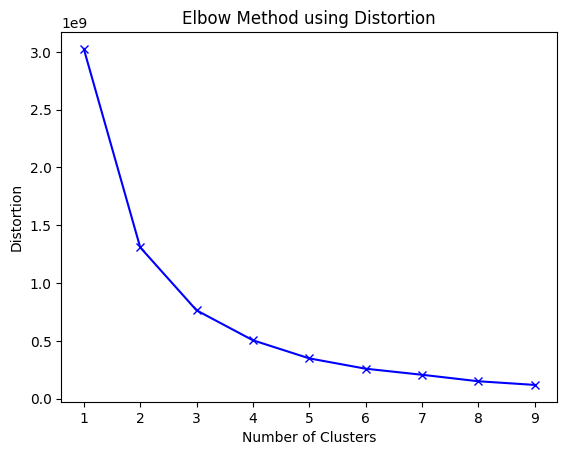

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
user_features['cluster'] = kmeans.fit_predict(user_feat_x)

cluster_summary = user_features.groupby('cluster').mean()
print(cluster_summary)

distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
    inertias.append(kmeanModel.inertia_)
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

print("\nDistortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method using Distortion')
plt.show()

### Dendrogram

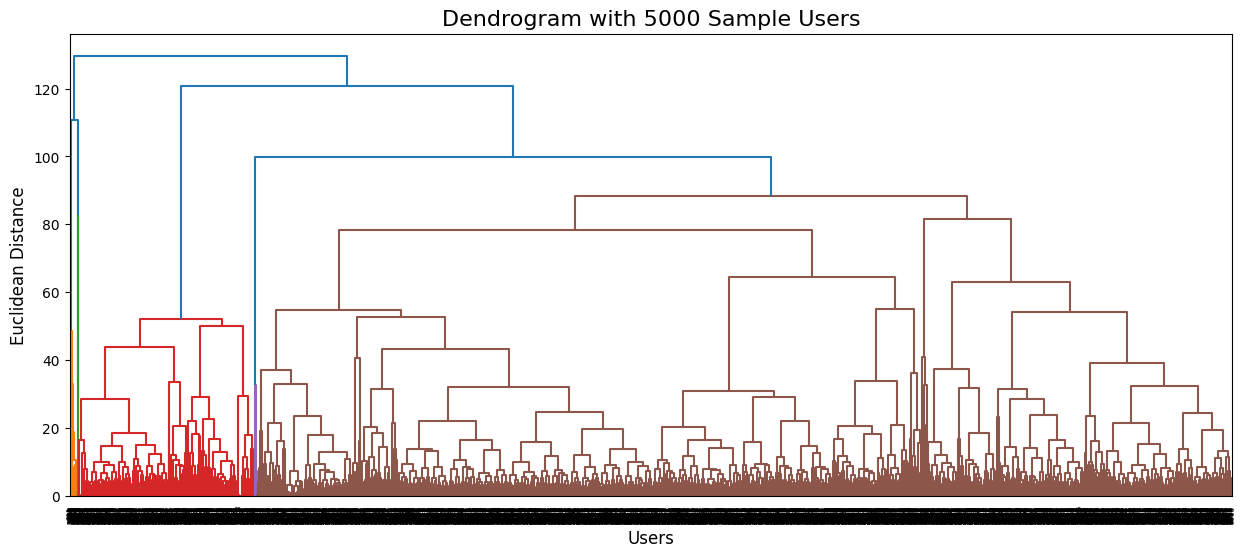

In [4]:
np.random.seed(42)
sample_size = 5000
sample_indices = np.random.choice(user_feat_x.shape[0], size=sample_size, replace=False)
X_scaled_sample = user_feat_x[sample_indices]

plt.figure(figsize=(15, 6))
plt.title('Dendrogram with 5000 Sample Users', fontsize=16)
plt.xlabel('Users', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)

dendrogram = sch.dendrogram(sch.linkage(X_scaled_sample, method='ward'))
plt.show()

### DBSCAN Clustering and K-Distance Graph

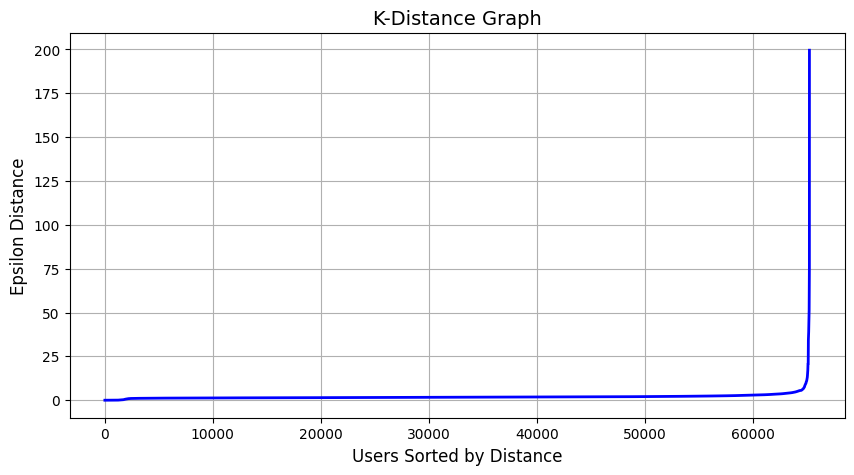

DBSCAN Summary:
 dbscan_cluster                            0            -1             1  \
user_count                     6.240700e+04  1.942000e+03  2.790000e+02   
steam_id                       7.656120e+16  7.656120e+16  7.656120e+16   
total_games                    1.635000e+01  8.380000e+00  1.889000e+01   
total_playtime                 4.141764e+04  4.266779e+04  4.321939e+04   
avg_price                      1.369000e+01  1.664000e+01  1.336000e+01   
pct_action                     7.700000e-01  5.900000e-01  7.600000e-01   
pct_adventure                  2.900000e-01  3.000000e-01  2.900000e-01   
pct_animation &amp; modeling   0.000000e+00  1.000000e-02  0.000000e+00   
pct_audio production           0.000000e+00  0.000000e+00  0.000000e+00   
pct_casual                     1.100000e-01  2.300000e-01  1.200000e-01   
pct_design &amp; illustration  0.000000e+00  1.000000e-02  0.000000e+00   
pct_early access               4.000000e-02  9.000000e-02  5.000000e-02   
pct_educ

In [5]:
neighbors = NearestNeighbors(n_neighbors=50)
neighbors_fit = neighbors.fit(user_feat_x)
distances, indices = neighbors_fit.kneighbors(user_feat_x)

distances = np.sort(distances[:, 49], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, color='blue', linewidth=2)
plt.title('K-Distance Graph', fontsize=14)
plt.xlabel('Users Sorted by Distance', fontsize=12)
plt.ylabel('Epsilon Distance', fontsize=12)
plt.grid(True)
plt.show()

OPTIMAL_EPS = 3
dbscan = DBSCAN(eps=OPTIMAL_EPS, min_samples=50)
user_features['dbscan_cluster'] = dbscan.fit_predict(user_feat_x)

dbscan_summary = user_features.groupby('dbscan_cluster').mean().round(2)
dbscan_counts = user_features['dbscan_cluster'].value_counts().rename("user_count")

final_dbscan = pd.concat([dbscan_counts, dbscan_summary], axis=1)
print("DBSCAN Summary:\n", final_dbscan.T)

### K-Means vs. DBSCAN

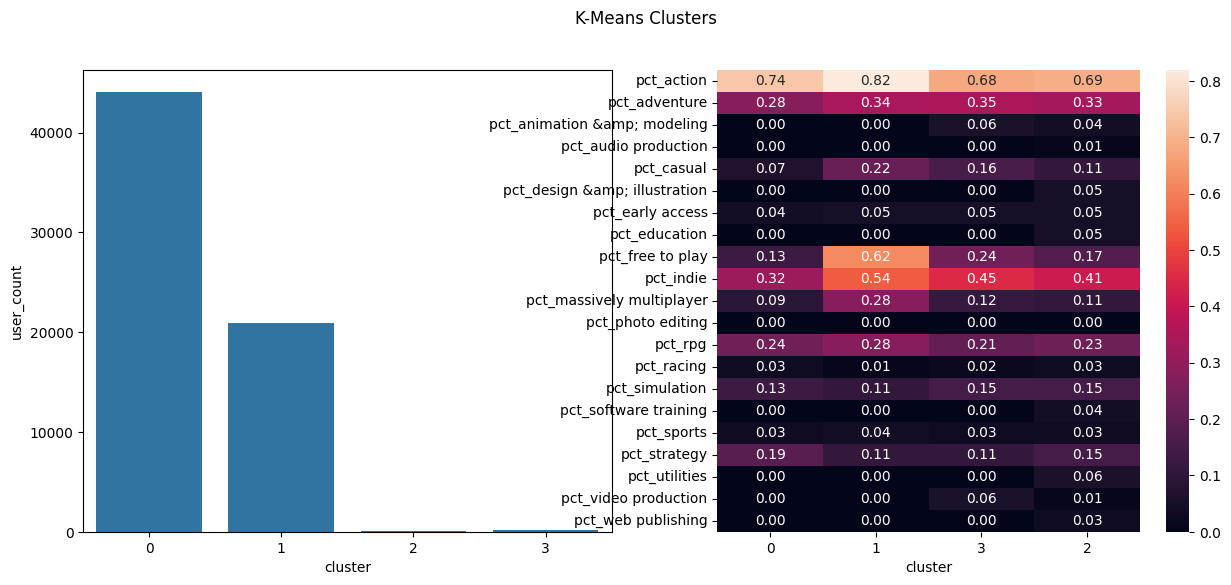

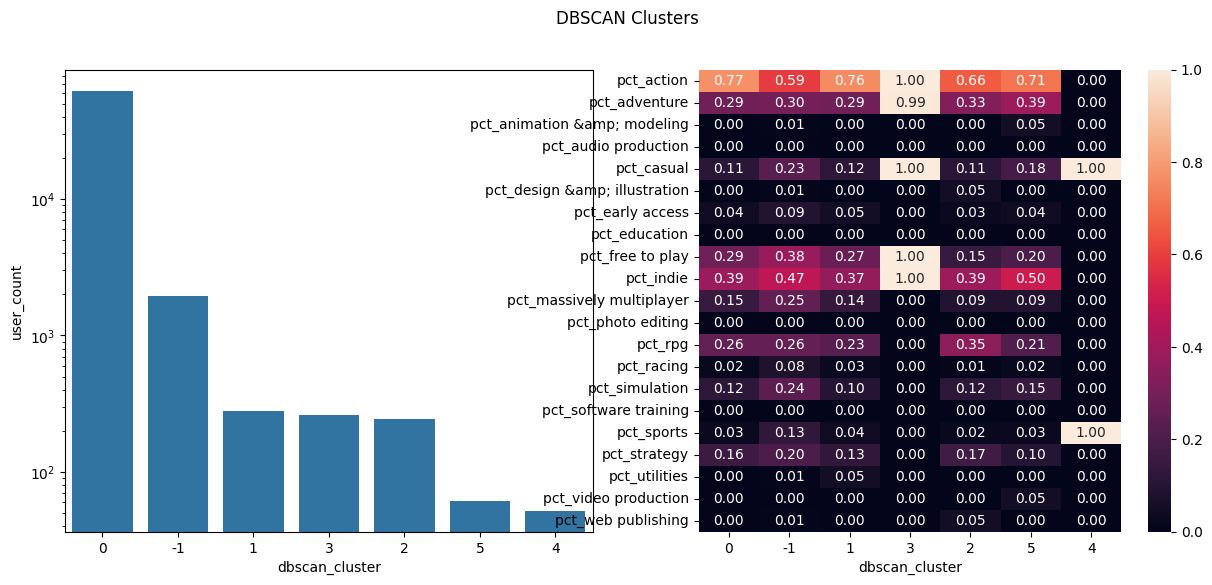

In [6]:
cluster_summary = user_features.groupby('cluster').mean().round(2)
cluster_counts = user_features['cluster'].value_counts().rename("user_count")
final_summary = pd.concat([cluster_counts, cluster_summary], axis=1)

genre_cols = [col for col in final_dbscan.columns if col.startswith('pct_')]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=final_summary.index, y=final_summary['user_count'], ax=axes[0])
sns.heatmap(final_summary[genre_cols].T, annot=True, fmt=".2f", ax=axes[1])
plt.suptitle('K-Means Clusters')
plt.show()

dbscan_sorted = final_dbscan.sort_values('user_count', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=dbscan_sorted.index, y=dbscan_sorted['user_count'], order=dbscan_sorted.index, ax=axes[0])
axes[0].set_yscale('log') 
sns.heatmap(dbscan_sorted[genre_cols].T, annot=True, fmt=".2f", ax=axes[1])
plt.suptitle('DBSCAN Clusters')
plt.show()

### Marketing Strategy and Segment Profiles

Marketing Strategies:
                            label                                                                 marketing                                                                 recommendation                                                               retention
cluster                                                                                                                                                                                                                                                          
0        Mainstream Action Gamer                   Promote premium releases, expansions, franchise sequels               Top-rated action/adventure, upcoming releases in wishlist genres                  Early access offers, loyalty discounts on new releases
1            Free-to-Play Casual                     In-game cosmetics, battle passes, limited-time events                Trending free titles, multiplayer games with active communities  Seasonal event r

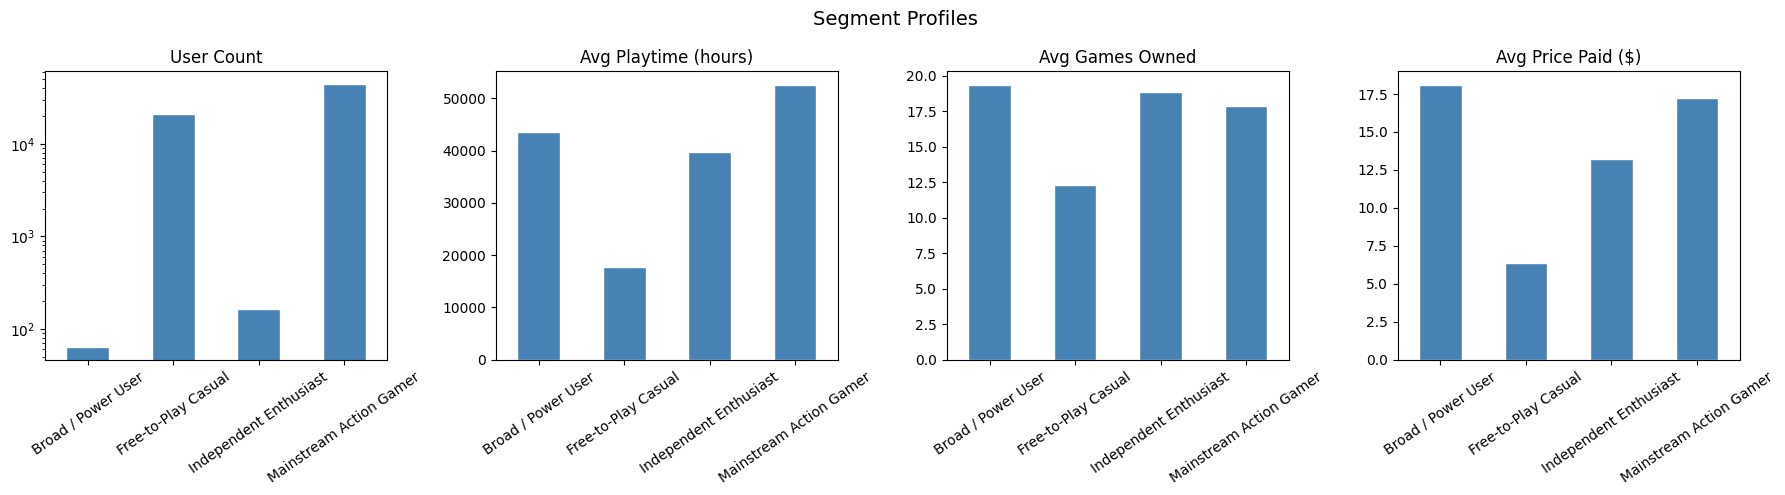

In [7]:
cluster_profiles = {
    0: {
        'label': 'Mainstream Action Gamer',
        'marketing': 'Promote premium releases, expansions, franchise sequels',
        'recommendation': 'Top-rated action/adventure, upcoming releases in wishlist genres',
        'retention': 'Early access offers, loyalty discounts on new releases'
    },
    1: {
        'label': 'Free-to-Play Casual',
        'marketing': 'In-game cosmetics, battle passes, limited-time events',
        'recommendation': 'Trending free titles, multiplayer games with active communities',
        'retention': 'Seasonal event reminders, social hooks (friend activity, leaderboards)'
    },
    3: {
        'label': 'Independent Enthusiast',
        'marketing': 'Independent developer bundles, developer spotlights, curated collections',
        'recommendation': 'Hidden gem independent games, games by followed developers, festival picks',
        'retention': 'Wishlist sale alerts, early access invites, developer update emails'
    },
    2: {
        'label': 'Broad / Power User',
        'marketing': 'Cross-sell software, creative tools, platform experiments',
        'recommendation': 'Surface tools and non-gaming content alongside games based on recent activity',
        'retention': 'Personalized weekly digest, feature discovery nudges'
    }
}

strategy_df = pd.DataFrame(cluster_profiles).T
strategy_df.index.name = 'cluster'
print("Marketing Strategies:\n", strategy_df.to_string())

label_map = {k: v['label'] for k, v in cluster_profiles.items()}
user_features['segment_label'] = user_features['cluster'].map(label_map)

segment_summary = user_features.groupby('segment_label').agg(
    user_count=('steam_id', 'count'),
    avg_playtime=('total_playtime', 'mean'),
    avg_games=('total_games', 'mean'),
    avg_spend=('avg_price', 'mean')
).round(2)

print("\nSegment Profiles:\n", segment_summary)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics = {
    'user_count': 'User Count',
    'avg_playtime': 'Avg Playtime (hours)',
    'avg_games': 'Avg Games Owned',
    'avg_spend': 'Avg Price Paid ($)'
}

for ax, (col, title) in zip(axes, metrics.items()):
    segment_summary[col].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=35)
    ax.set_xlabel('')
    if col == 'user_count':
        ax.set_yscale('log')

plt.suptitle('Segment Profiles', fontsize=14)
plt.tight_layout()
plt.show()

### Results

K-Means provides a clean four-cluster solution that holds up well for practical user segmentation; the dominant group of players of action and independent games, a free-to-play casual group, and two smaller but distinct niches. DBSCAN generally aligns with this main structure, but reveals interesting micro-clusters; users who play exclusively sports or casual games, which K-Means misses. The DBSCAN noise group of around 1500 users also highlights that some users don't fit into any specfic behavioral patterns.